R=array([[0.85714286, 0.5       , 0.125     , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.14285714, 0.5       , 0.75      , 0.5       , 0.125     ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.125     , 0.5       , 0.75      ,
        0.5       , 0.125     , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.125     ,
        0.5       , 0.75      , 0.5       , 0.125     , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.125     , 0.5       , 0.75      , 0.5       ,
        0.125     ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.125     , 0.5       ,
        0.75      ],
       [0.        , 0.        , 0.        , 0.        , 

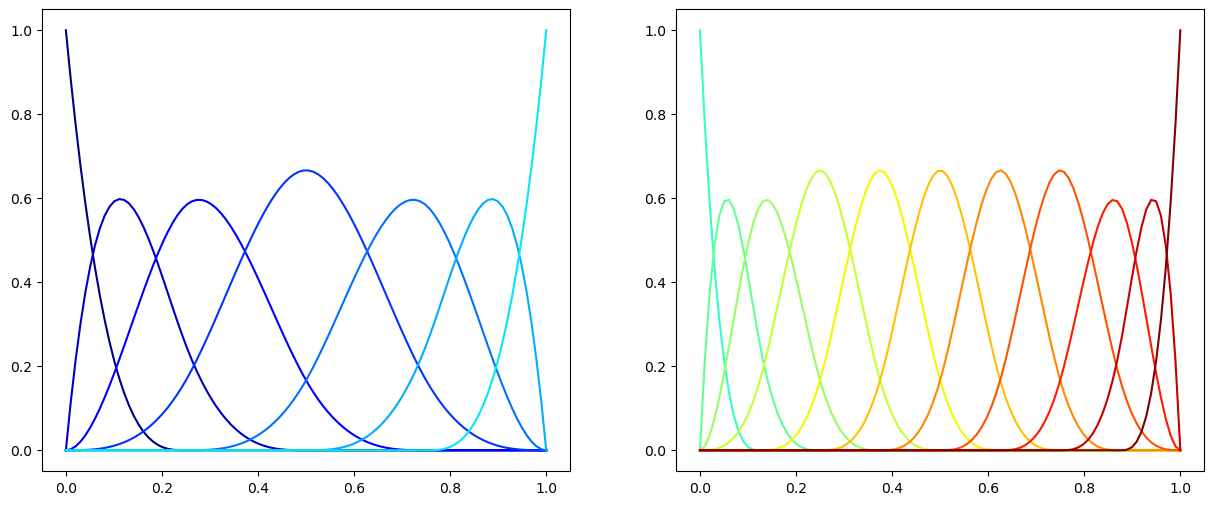

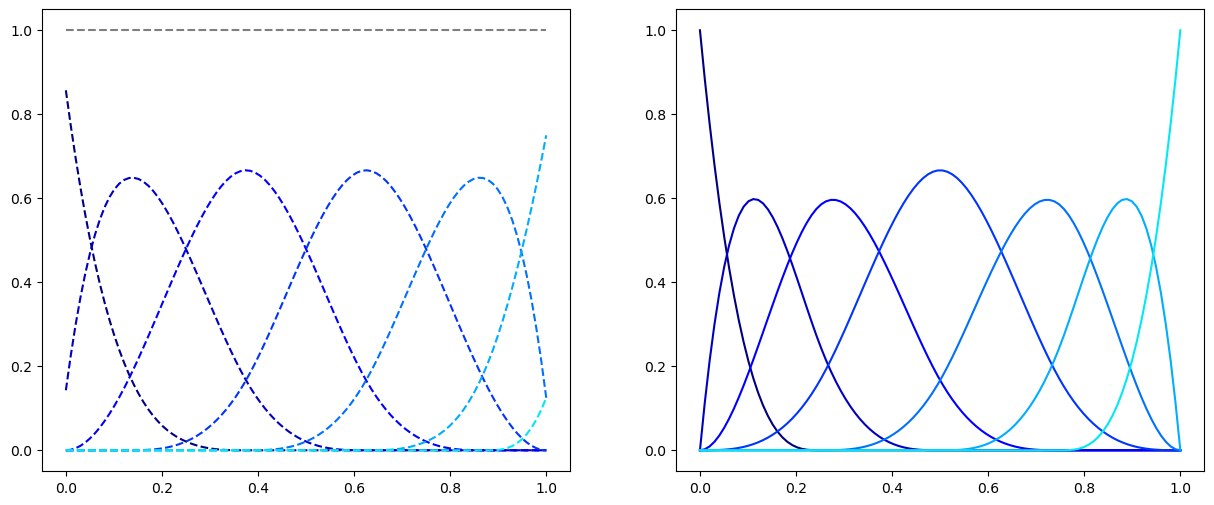

In [6]:

"""
multigrid restrict / prolong from 3rd to 2nd order IGA 
"""

import numpy as np
import matplotlib.pyplot as plt

p = 3

def cubic_bernstein(xi):
    N  = np.array([
        (1 - xi)**3,
        3*xi*(1 - xi)**2,
        3*xi**2*(1 - xi),
        xi**3
    ])
    dN = np.array([
        -3*(1 - xi)**2,
        3*(1 - xi)**2 - 6*xi*(1 - xi),
        6*xi*(1 - xi) - 3*xi**2,
        3*xi**2
    ])
    return N, dN


u = np.linspace(0.0, 1.0, 100)

def build_basis(nxe):
    nglob = nxe+p # number of global basis functions
    colors = plt.cm.jet(np.linspace(0.0, 1.0, nglob))
    knots = [0.0]*(p+1) + [i/nxe for i in range(1,nxe)] + [1.0]*(p+1)
    global_basis = np.zeros((nglob, u.shape[0]))
    elem_conn = [
        [i, i+1, i+2, i+3] for i in range(nxe) # element connectivity
    ]
    for ielem in range(nxe):
    # for ielem in range(1):
        knot1, knot2 = knots[p+ielem], knots[p+ielem+1]
        # compute normalized coordinates in here
        xi = (u - knot1) / (knot2 - knot1)
        # zero out using mask products if xi not in 0, 1
        xi_mask = np.logical_and(xi >= 0.0, xi <= 1.0)
        # compute bernstein coefficients
        B, dB = cubic_bernstein(xi)

        first_elem  = (ielem == 0)
        second_elem = (ielem == 1)
        last_elem   = (ielem == nxe - 1)
        second_last = (ielem == nxe - 2)
        interior    = not (first_elem or second_elem or last_elem or second_last)

        if first_elem:
            N0 = 1.0 * B[0]
            N1 = 1.0 * B[1] + 0.5 * B[2] + 0.25 * B[3]
            N2 = 0.5 * B[2] + (7.0/12.0) * B[3]
            N3 = (1.0/6.0) * B[3]

        elif second_elem:
            N0 = 0.25 * B[0]
            N1 = (7.0/12.0)*B[0] + (2.0/3.0)*B[1] + (1.0/3.0)*B[2] + (1.0/6.0)*B[3]
            N2 = (1.0/6.0)*B[0] + (1.0/3.0)*B[1] + (2.0/3.0)*B[2] + (2.0/3.0)*B[3]
            N3 = (1.0/6.0) * B[3]

        elif second_last:
            # mirror of second
            N0 = (1.0/6.0) * B[0]
            N1 = (2.0/3.0)*B[0] + (2.0/3.0)*B[1] + (1.0/3.0)*B[2] + (1.0/6.0)*B[3]
            N2 = (1.0/6.0)*B[0] + (1.0/3.0)*B[1] + (2.0/3.0)*B[2] + (7.0/12.0)*B[3]
            N3 = 0.25 * B[3]

        elif last_elem:
            # mirror of first
            N0 = (1.0/6.0) * B[0]
            N1 = (7.0/12.0) * B[0] + 0.5 * B[1]
            N2 = 0.25 * B[0] + 0.5 * B[1] + 1.0 * B[2]
            N3 = 1.0 * B[3]

        else:  # interior
            N0 = (1.0/6.0) * B[0]

            N1 = (2.0/3.0)*B[0] + (2.0/3.0)*B[1] \
            + (1.0/3.0)*B[2] + (1.0/6.0)*B[3]

            N2 = (1.0/6.0)*B[0] + (1.0/3.0)*B[1] \
            + (2.0/3.0)*B[2] + (2.0/3.0)*B[3]

            N3 = (1.0/6.0) * B[3]

        # now add into these basis functions if they exist
        local_conn = elem_conn[ielem]
        g0, g1, g2, g3 = local_conn[0], local_conn[1], local_conn[2], local_conn[3]
        global_basis[g0] += N0 * xi_mask
        global_basis[g1] += N1 * xi_mask
        global_basis[g2] += N2 * xi_mask
        global_basis[g3] += N3 * xi_mask

    return global_basis



# ===========================================
# plot the fine and coarse global bases
# ===========================================

# construct fine and coarse bases
# nxe_f = 2
nxe_f = 8
# nxe_f = 16

nxe_c = nxe_f // 2
n_fine = nxe_f + p
n_coarse = nxe_c + p

fine_basis = build_basis(nxe_f)
coarse_basis = build_basis(nxe_c)

n_tot = n_fine + n_coarse
colors = plt.cm.jet(np.linspace(0.0, 1.0, n_tot))

# re-plot fine and coarse bases
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

for i in range(n_coarse):
    ax[0].plot(u, coarse_basis[i], color=colors[i])
for i in range(n_fine):
    ax[1].plot(u, fine_basis[i], color=colors[i+n_coarse])


# ===========================================
# restriction here..
# ===========================================

def restriction_p3_h2_wrong_method(nxe_f):
    _p = 3
    nxe_c = nxe_f // 2
    n_fine = nxe_f + _p
    n_coarse = nxe_c + _p

    R = np.zeros((n_coarse, n_fine))
    # counts = 1e-14 * np.ones_like(R)
    # counts = np.zeros(n_coarse)

    mask = np.array([1, 4, 6, 4, 1], dtype=float) / 8.0  # length 5

    # Interior mapping guess:
    # coarse i mostly lives over fine indices ~ 2*i (same “doubling” logic you used in p=2)
    for i in range(n_coarse):
        j0 = 2*i - 2  # shift so the 5-pt stencil sits sensibly (tweakable)
        for k in range(5):
            j = j0 + k
            if 0 <= j < n_fine:
                R[i, j] += mask[k]
                # counts[i, j] += 1.0
                # counts[i] += 1.0

    # normalize like your code does when overlaps accumulate / boundaries truncate
    # R /= counts
    R /= np.sum(R, axis=0)[None,:]
    # R /= np.sum(R, axis=1)
    # R /= np.sum(R, axis=1)[:, None]
    return R



R = restriction_p3_h2_wrong_method(nxe_f)
print(f"{R=}")
coarse_basis_v2 = np.dot(R, fine_basis)



fig, ax = plt.subplots(1, 2, figsize=(15, 6))
for i in range(n_coarse):
    ax[0].plot(u, coarse_basis_v2[i], '--', color=colors[i])
ax[0].plot(u, np.ones(100), '--', color="tab:gray")
for i in range(n_coarse):
    ax[1].plot(u, coarse_basis[i], color=colors[i])

N_H=array([[ 1.66666667e-01, -5.00000000e-01,  5.00000000e-01,
        -1.66666667e-01],
       [ 6.66666667e-01, -1.11022302e-16, -1.00000000e+00,
         5.00000000e-01],
       [ 1.66666667e-01,  5.00000000e-01,  5.00000000e-01,
        -5.00000000e-01],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.66666667e-01]])
R_left_basis=array([[ 5.00000000e-01,  1.25000000e-01, -0.00000000e+00,
        -8.32667268e-17],
       [ 5.00000000e-01,  7.50000000e-01,  5.00000000e-01,
         1.25000000e-01],
       [ 5.55111512e-17,  1.25000000e-01,  5.00000000e-01,
         7.50000000e-01],
       [ 0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
         1.25000000e-01]])
R_right_basis=array([[ 1.25000000e-01, -0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 7.50000000e-01,  5.00000000e-01,  1.25000000e-01,
        -3.33066907e-15],
       [ 1.25000000e-01,  5.00000000e-01,  7.50000000e-01,
         5.00000000e-01],
       [ 1.85037171e-17, -3.7007

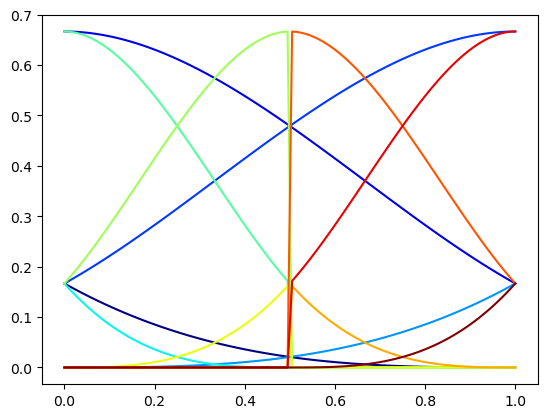

In [7]:
"""
Do some symbolic math here to discover the coefficients of interior restriction operator first
"""
import numpy as np
import matplotlib.pyplot as plt

# cubic bernstein to basis matrix
BtoN = np.array([
    [1.0 / 6.0, 0.0, 0.0, 0.0],
    [2.0/3.0, 2.0/3.0, 1.0/3.0, 1.0/6.0],
    [1.0/6.0,1.0/3.0, 2.0/3.0, 2.0/3.0],
    [0.0, 0.0, 0.0, 1.0/6.0]
])
# coarse cubic bernstein
Bc = np.array([
    [1, -3, 3, -1], # (1-xi)^3
    [0, 3, -6, 3],  # 3*xi*(1-xi)^2
    [0, 0, 3, -3],  # 3*xi^2*(1-xi)
    [0, 0, 0, 1]    # xi^3
])

# coarse basis functions
N_H = BtoN @ Bc
print(f"{N_H=}")

# plot coarse basis
xi = np.linspace(0.0, 1.0, 100)
colors = plt.cm.jet(np.linspace(0.0, 1.0, 12))
for i in range(4):
    frow = N_H[i]
    f = frow[0] + frow[1] * xi + frow[2] * xi**2 + frow[3] * xi**3
    plt.plot(xi, f, color=colors[i])
# plt.show()

# ======================================
# left half fine basis 
# ======================================

# left half fine basis (uses xi_f = 2*xi substitution)
# left half cubic bernstein with xi_f = 2*xi
B_Lf = np.array([
    [1, -6, 12, -8], # (1-2*xi)^3
    [0, 6, -24, 24], # 3*2xi*(1-2*xi)^2
    [0, 0, 12, -24], # 3*(2*xi)^2*(1-2*xi)
    [0, 0, 0, 8],    # 8*xi^3
])
# compute and plot fine basis
N_Lh = BtoN @ B_Lf
for j in range(4):
    frow = N_Lh[j]
    f = frow[0] + frow[1] * xi + frow[2] * xi**2 + frow[3] * xi**3
    f *= xi <= 0.5 # xi_mask
    plt.plot(xi, f, color=colors[4+j])
# plt.show()
# inverse matrix (see 4_multigrid_oned.ipynb for how to get this equation from restriction operator)
R_left_basis = np.linalg.solve(N_Lh.T, N_H.T).T
print(f"{R_left_basis=}")
# gives:
R_left_basis = np.array([
    [0.5, 0.125, 0.0, 0.0],
    [0.5, 0.75, 0.5, 0.125],
    [0.0, 0.125, 0.5, 0.75],
    [0.0, 0.0, 0.0, 0.125],
])

# ======================================
# right half fine basis 
# ======================================

# right half fine basis (uses xi_f = 2*xi-1 substitution)
B_Rf = np.array([
    [8, -24, 24, -8],   # (2-2*xi)^3
    [-12, 48, -60, 24], # 3*(2xi-1)*(2-2*xi)^2
    [6, -30, 48, -24],  # 3*(2*xi-1)^2*(2-2*xi)
    [-1, 6, -12, 8], # (2*xi-1)^3
])
N_Rh = BtoN @ B_Rf
# inverse matrix (see 4_multigrid_oned.ipynb for how to get this equation from restriction operator)
R_right_basis = np.linalg.solve(N_Rh.T, N_H.T).T
print(f"{R_right_basis=}")
# gives:
R_right_basis = np.array([
    [0.125, 0.0, 0.0, 0.0],
    [0.75, 0.5, 0.125, 0.0],
    [0.125, 0.5, 0.75, 0.5],
    [0.0, 0.0, 0.125, 0.5],
])

# =============================================
# assemble into local fine to coarse restriction stencil
# =============================================

R = np.zeros((4, 5))
R[:,:4] += R_left_basis #.T
R[:,1:] += R_right_basis #.T
R /= np.sum(R, axis=0)
print(f"{R=}")
# gives
R = np.array([[0.5 , 0.125, 0.  , 0.  , 0.  ],
       [0.5 , 0.75 , 0.5  , 0.125, 0.  ],
       [0.  , 0.125, 0.5  , 0.75 , 0.5 ],
       [0.  , 0.  , 0.  , 0.125, 0.5 ]])

for j in range(4):
    frow = N_Rh[j]
    f = frow[0] + frow[1] * xi + frow[2] * xi**2 + frow[3] * xi**3
    f *= xi >= 0.5 # xi_mask
    plt.plot(xi, f, color=colors[8+j])
# plt.show()

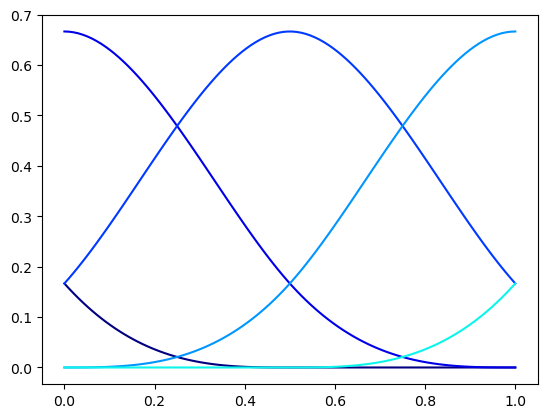

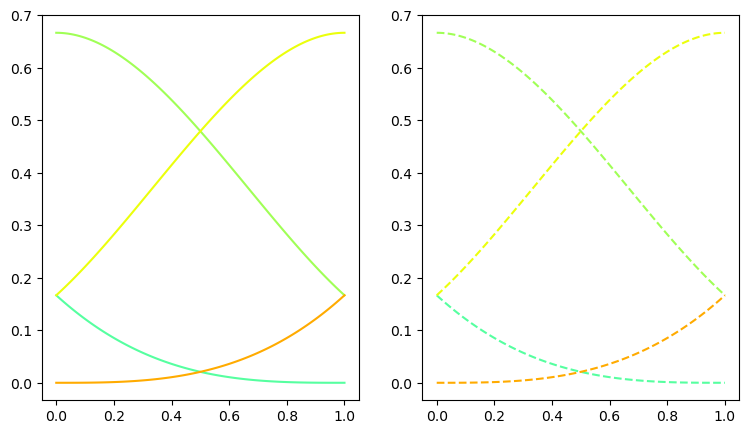

In [8]:
# try to reconstruct coarse basis using new local restriction operator

# build fine basis functions
N_h_plot = np.zeros((5, 100))
for j in range(4):
    frow = N_Lh[j]
    f = frow[0] + frow[1] * xi + frow[2] * xi**2 + frow[3] * xi**3
    f *= xi <= 0.5 # xi_mask
    N_h_plot[j] += f
    
    frow = N_Rh[j]
    f = frow[0] + frow[1] * xi + frow[2] * xi**2 + frow[3] * xi**3
    f *= xi > 0.5 # xi_mask
    N_h_plot[1+j] += f

# build coarse basis from functions
N_H_plot = np.zeros((4, 100))
for i in range(4):
    frow = N_H[i]
    f = frow[0] + frow[1] * xi + frow[2] * xi**2 + frow[3] * xi**3
    N_H_plot[i] += f

# plot fine basis
for i in range(5):
    plt.plot(xi, N_h_plot[i], color=colors[i])
plt.show()

# =======================================
# now try to reconstruct the coarse basis using the fine basis prolongation matrix we just built
# =======================================

fig, ax = plt.subplots(1, 2, figsize=(9, 5))
N_H_plot_v2 = np.dot(R, N_h_plot)
for i in range(4):
    ax[0].plot(xi, N_H_plot[i], color=colors[i+5])
    ax[1].plot(xi, N_H_plot_v2[i], '--', color=colors[i+5])
plt.show()

# it worked!

In [13]:
# now compute restriction matrix again for each case of coarse element near left, and right boundaries including one element over..
# hard-code the new restriction matrix process.. as above..
# do it for case with 6 elements (so two interior) just to see..

def get_BtoN_matrix(ielem, nxe):
    first_elem  = (ielem == 0)
    second_elem = (ielem == 1)
    last_elem   = (ielem == nxe - 1)
    second_last = (ielem == nxe - 2)
    interior    = not (first_elem or second_elem or last_elem or second_last)

    # cubic bernstein to basis matrix
    if first_elem:
        BtoN = np.array([
            [1.0, 0.0, 0.0, 0.0],
            [0.0, 1.0, 0.5, 0.25],
            [0.0, 0.0, 0.5, 7.0/12.0],
            [0.0, 0.0, 0.0, 1.0/6.0]
        ])

    elif second_elem:
        BtoN = np.array([
            [0.25, 0.0, 0.0, 0.0],
            [7.0/12.0, 2.0/3.0, 1.0/3.0, 1.0/6.0],
            [1.0/6.0, 1.0/3.0, 2.0/3.0, 2.0/3.0],
            [0.0, 0.0, 0.0, 1.0/6.0]
        ])

    elif second_last:
        BtoN = np.array([
            [1.0/6.0, 0.0, 0.0, 0.0],
            [2.0/3.0, 2.0/3.0, 1.0/3.0, 1.0/6.0],
            [1.0/6.0, 1.0/3.0, 2.0/3.0, 7.0/12.0],
            [0.0, 0.0, 0.0, 0.25]
        ])

    elif last_elem:
        BtoN = np.array([
            [1.0/6.0, 0.0, 0.0, 0.0],
            [7.0/12.0, 0.5, 0.0, 0.0],
            [0.25, 0.5, 1.0, 0.0],
            [0.0, 0.0, 0.0, 1.0]
        ])

    else:  # interior
        BtoN = np.array([
            [1.0 / 6.0, 0.0, 0.0, 0.0],
            [2.0/3.0, 2.0/3.0, 1.0/3.0, 1.0/6.0],
            [1.0/6.0,1.0/3.0, 2.0/3.0, 2.0/3.0],
            [0.0, 0.0, 0.0, 1.0/6.0]
        ])

    return BtoN

def build_local_restriction_matrix(ielem_c, nxe_c):

    BtoN_c = get_BtoN_matrix(ielem_c, nxe_c)
    BtoN_Lf = get_BtoN_matrix(2*ielem_c, 2*nxe_c)
    BtoN_Rf = get_BtoN_matrix(2*ielem_c+1, 2*nxe_c)
    # print(f"{ielem_c=}")
    # print(f"\t{BtoN_c=}")
    # print(f"\t{BtoN_Lf=}")
    # print(f"\t{BtoN_Rf=}")

    # coarse cubic bernstein
    Bc = np.array([
        [1, -3, 3, -1], # (1-xi)^3
        [0, 3, -6, 3],  # 3*xi*(1-xi)^2
        [0, 0, 3, -3],  # 3*xi^2*(1-xi)
        [0, 0, 0, 1]    # xi^3
    ])

    # coarse basis functions
    N_H = BtoN_c @ Bc

    # ======================================
    # left half fine basis 
    # ======================================

    # left half fine basis (uses xi_f = 2*xi substitution)
    # left half cubic bernstein with xi_f = 2*xi
    B_Lf = np.array([
        [1, -6, 12, -8], # (1-2*xi)^3
        [0, 6, -24, 24], # 3*2xi*(1-2*xi)^2
        [0, 0, 12, -24], # 3*(2*xi)^2*(1-2*xi)
        [0, 0, 0, 8],    # 8*xi^3
    ])
    # compute and plot fine basis
    N_Lh = BtoN_Lf @ B_Lf
    # inverse matrix (see 4_multigrid_oned.ipynb for how to get this equation from restriction operator)
    R_left_basis = np.linalg.solve(N_Lh.T, N_H.T).T

    # ======================================
    # right half fine basis 
    # ======================================

    # right half fine basis (uses xi_f = 2*xi-1 substitution)
    B_Rf = np.array([
        [8, -24, 24, -8],   # (2-2*xi)^3
        [-12, 48, -60, 24], # 3*(2xi-1)*(2-2*xi)^2
        [6, -30, 48, -24],  # 3*(2*xi-1)^2*(2-2*xi)
        [-1, 6, -12, 8], # (2*xi-1)^3
    ])
    N_Rh = BtoN_Rf @ B_Rf
    # inverse matrix (see 4_multigrid_oned.ipynb for how to get this equation from restriction operator)
    R_right_basis = np.linalg.solve(N_Rh.T, N_H.T).T

    # =============================================
    # assemble into local fine to coarse restriction stencil
    # =============================================

    R = np.zeros((4, 5))
    R[:,:4] += R_left_basis #.T
    R[:,1:] += R_right_basis #.T
    R /= np.sum(R, axis=0)

    return R_left_basis, R_right_basis, R


nxe = 6
for ielem in range(nxe):
    R_left, R_right, R_loc = build_local_restriction_matrix(ielem, nxe)
    print(f"{ielem=}:")
    print(f"\t{R_left=}")
    print(f"\t{R_right=}")
    print(f"\t{R_loc=}")
    print("================================")

ielem=0:
	R_left=array([[ 1.00000000e+00,  5.00000000e-01, -0.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  5.00000000e-01,  7.50000000e-01,
         1.87500000e-01],
       [ 1.11022302e-16,  1.11022302e-16,  2.50000000e-01,
         6.87500000e-01],
       [ 0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
         1.25000000e-01]])
	R_right=array([[ 5.00000000e-01, -0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 5.00000000e-01,  7.50000000e-01,  1.87500000e-01,
        -5.57887070e-15],
       [-2.96059473e-16,  2.50000000e-01,  6.87500000e-01,
         5.00000000e-01],
       [-6.57384088e-32, -3.70074342e-17,  1.25000000e-01,
         5.00000000e-01]])
	R_loc=array([[ 1.00000000e+00,  5.00000000e-01,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  5.00000000e-01,  7.50000000e-01,
         1.87500000e-01, -5.57887070e-15],
       [ 1.11022302e-16, -9.25185854e-17,  2.50000000e-01,
         6.87500000e-0

R=array([[1.    , 0.5   , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.    , 0.    ],
       [0.    , 0.5   , 0.75  , 0.1875, 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.25  , 0.6875, 0.5   , 0.125 , 0.    , 0.    ,
        0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , 0.125 , 0.5   , 0.75  , 0.5   , 0.125 ,
        0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , 0.    , 0.    , 0.125 , 0.5   , 0.6875,
        0.25  , 0.    , 0.    ],
       [0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.1875,
        0.75  , 0.5   , 0.    ],
       [0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.5   , 1.    ]])


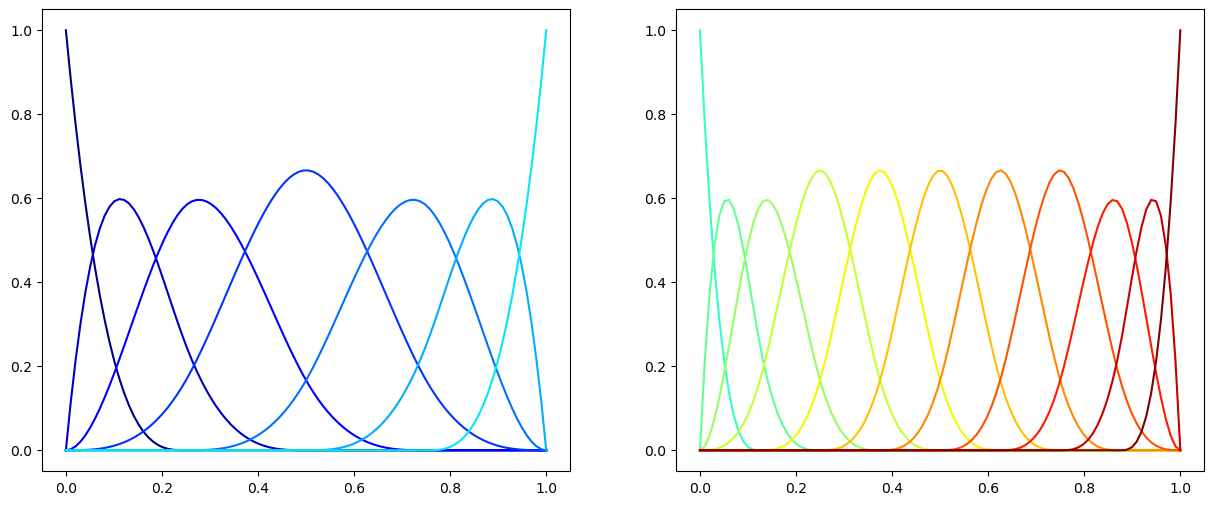

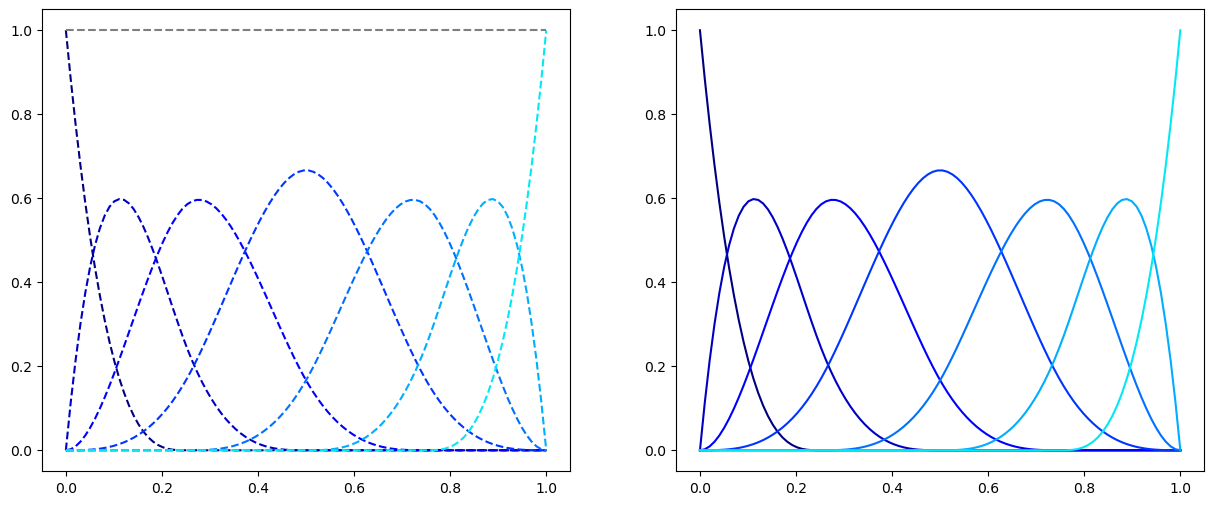

In [19]:
# now try restriction again globally with corrected stencil..


# ===========================================
# plot the fine and coarse global bases
# ===========================================

# construct fine and coarse bases
# nxe_f = 2
nxe_f = 8
# nxe_f = 16

nxe_c = nxe_f // 2
n_fine = nxe_f + p
n_coarse = nxe_c + p

fine_basis = build_basis(nxe_f)
coarse_basis = build_basis(nxe_c)

n_tot = n_fine + n_coarse
colors = plt.cm.jet(np.linspace(0.0, 1.0, n_tot))

# re-plot fine and coarse bases
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

for i in range(n_coarse):
    ax[0].plot(u, coarse_basis[i], color=colors[i])
for i in range(n_fine):
    ax[1].plot(u, fine_basis[i], color=colors[i+n_coarse])


# ===========================================
# restriction here..
# ===========================================

def restriction_p3_h2_new(nxe_f):
    _p = 3
    nxe_c = nxe_f // 2
    n_fine = nxe_f + _p
    n_coarse = nxe_c + _p

    R = np.zeros((n_coarse, n_fine))
    # counts = 1e-14 * np.ones_like(R)
    # counts = np.zeros(n_coarse)

    for ielem in range(nxe_c):

        # choose local restriction based on coarse element index
        if ielem == 0:
            R_loc = np.array([
                [1.0   , 0.5   , 0.0   , 0.0   , 0.0],
                [0.0   , 0.5   , 0.75  , 0.1875, 0.0],
                [0.0   , 0.0   , 0.25  , 0.6875, 0.5],
                [0.0   , 0.0   , 0.0   , 0.125 , 0.5]
            ])

        elif ielem == 1:
            R_loc = np.array([
                [0.75  , 0.1875, 0.0   , 0.0   , 0.0],
                [0.25  , 0.6875, 0.5   , 0.125 , 0.0],
                [0.0   , 0.125 , 0.5   , 0.75  , 0.5],
                [0.0   , 0.0   , 0.0   , 0.125 , 0.5]
            ])

        elif ielem == nxe_c - 2:  # second to last
            R_loc = np.array([
                [0.5   , 0.125 , 0.0   , 0.0   , 0.0],
                [0.5   , 0.75  , 0.5   , 0.125 , 0.0],
                [0.0   , 0.125 , 0.5   , 0.6875, 0.25],
                [0.0   , 0.0   , 0.0   , 0.1875, 0.75]
            ])

        elif ielem == nxe_c - 1:  # last element
            R_loc = np.array([
                [0.5   , 0.125 , 0.0   , 0.0   , 0.0],
                [0.5   , 0.6875, 0.25  , 0.0   , 0.0],
                [0.0   , 0.1875, 0.75  , 0.5   , 0.0],
                [0.0   , 0.0   , 0.0   , 0.5   , 1.0]
            ])

        else:  # interior
            R_loc = np.array([
                [0.5   , 0.125 , 0.0   , 0.0   , 0.0],
                [0.5   , 0.75  , 0.5   , 0.125 , 0.0],
                [0.0   , 0.125 , 0.5   , 0.75  , 0.5],
                [0.0   , 0.0   , 0.0   , 0.125 , 0.5]
            ])

        # add in coarse elem restriction
        R[ielem:(ielem+4), 2*ielem:(2*ielem+5)] += R_loc

    # plt.imshow(R)
    # plt.show(R)
    # print(f"{R=}")
    R /= np.sum(R, axis=0) # normalize if prolongated, results in right values usually
    return R



R = restriction_p3_h2_new(nxe_f)
print(f"{R=}")
coarse_basis_v2 = np.dot(R, fine_basis)



fig, ax = plt.subplots(1, 2, figsize=(15, 6))
for i in range(n_coarse):
    ax[0].plot(u, coarse_basis_v2[i], '--', color=colors[i])
ax[0].plot(u, np.ones(100), '--', color="tab:gray")
for i in range(n_coarse):
    ax[1].plot(u, coarse_basis[i], color=colors[i])